In [39]:
import pandas as pd

orders = pd.read_csv("olist_orders_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")

df = orders.merge(customers,on="customer_id")
df = df.merge(payments, on="order_id")

print(df.head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
3    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
4    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2017-10-04 19:55:00           2017-10

In [40]:
top_cities = (
    df.groupby("customer_city")["order_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)
print(top_cities)

customer_city
sao paulo                16221
rio de janeiro            7207
belo horizonte            2872
brasilia                  2193
curitiba                  1576
campinas                  1515
porto alegre              1418
salvador                  1347
guarulhos                 1250
sao bernardo do campo      979
Name: order_id, dtype: int64


In [41]:
repeat_customers = (
    df.groupby("customer_unique_id")["order_id"]
    .count()
    .reset_index()
)
repeat_customers = repeat_customers[repeat_customers["order_id"]>1]
print(repeat_customers.head())


                   customer_unique_id  order_id
19   000e309254ab1fc5ba99dd469d36bdb4         2
33   00172711b30d52eea8b313a7f2cced02         2
55   0028a7d8db7b0247652509358ad8d755         2
73   00324c9f4d710e7bac5c5ba679714430         2
106  004288347e5e88a27ded2bb23747066c         2


In [42]:
total_revenue = df["payment_value"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 16008872.120000001


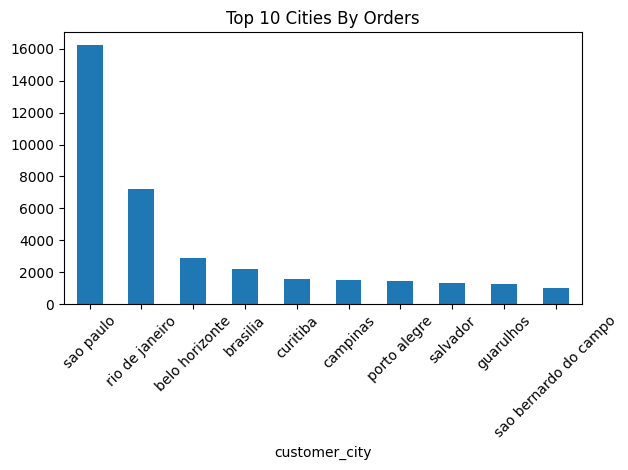

In [43]:
import matplotlib.pyplot as plt

top_cities.plot(kind="bar")
plt.title("Top 10 Cities By Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()